In [ ]:
import warnings
from pathlib import Path
from shutil import rmtree
from json import dumps
from typing import Literal
from pickle import Pickler
from gzip import open as gz_open
from joblib import Memory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector
from sklearn.metrics import make_scorer, f1_score
from imblearn.ensemble import BalancedRandomForestClassifier


RANDOM_STATE = 42
RANDOM_RNG = np.random.default_rng(42)
VIF_THRESHOLD = 10.0

# Data

In [2]:
def get_vif_removal_features(threshold: float) -> frozenset[str]:
    vif_values = Path("../datasense/dataset/vif_values.csv")
    vif_values = pd.read_csv(vif_values)
    vif_values = vif_values[vif_values["vif"] >= threshold]
    return frozenset(vif_values["feature"])


def get_transformer(data: pd.DataFrame, vif_threshold: float = VIF_THRESHOLD):
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    first_transformer = make_column_transformer(
        (OneHotEncoder(sparse_output=False), ["device_type"]),
        ("passthrough", number_selector),
        ("passthrough", bool_selector),
        remainder="drop",
        verbose_feature_names_out=False,
    )
    _ = first_transformer.fit_transform(data)
    feature_names = first_transformer.get_feature_names_out()
    vif_removal = get_vif_removal_features(vif_threshold)
    vif_indexes = [i for i, ft in enumerate(feature_names) if ft in vif_removal]
    second_transformer = make_column_transformer(
        ("drop", vif_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    )
    return make_pipeline(first_transformer, second_transformer)


def prepare_experiment(
    target: Literal["binary", "condensed", "granular"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_1sec_{split}.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "condensed":
            y_split = split_data["label2"]
        elif target == "granular":
            y_split = split_data["label4"]
        else:
            raise ValueError("Unknown target")
        experiment[split] = (split_data, y_split)
    X_train, y_train = experiment["train"]
    experiment["classes"] = sorted(y_train.unique())
    experiment["transformer"] = get_transformer(X_train)
    results_dir = Path(f"results/random_forest__{target}")
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError(
                "Experiment already executed and overwrite set to False"
            )
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = Memory(location=cache_dir, verbose=0)
    return experiment


def get_sampling_strategy(y):
    class_names, counts = np.unique(y, return_counts=True)
    minority = int(counts.min())
    if len(class_names) < 3:
        target_size = round(minority / 4)
        return {cls_name: target_size for cls_name in class_names}
    if len(class_names) == 8:
        return {cls_name: minority for cls_name in class_names}
    return {
        cls_name: min(int(counts[i]), 100 * minority)
        for i, cls_name in enumerate(class_names)
    }


def get_class_weight(y):
    sample_strategy = get_sampling_strategy(y)
    num_classes = len(sample_strategy)
    total_samples = sum(sample_strategy.values())
    return {
        cls_name: round(total_samples / (num_classes * count), 2)
        for cls_name, count in sample_strategy.items()
    }


def get_param_grid(num_classes):
    param_grid = {
        "model__criterion": ["gini", "entropy"],
        "model__max_features": [0.25, 0.5],
        "model__min_samples_leaf": [3, 5, 7],
    }
    if num_classes < 3:
        param_grid["model__n_estimators"] = [100, 150, 200]
        param_grid["model__max_leaf_nodes"] = [300, 600, 900]
    elif num_classes == 8:
        param_grid["model__n_estimators"] = [75, 100, 125]
        param_grid["model__max_leaf_nodes"] = [600, 900, 1200]
    else:
        param_grid["model__n_estimators"] = [30, 40, 50]
        param_grid["model__max_leaf_nodes"] = [1200, 1800, 2400]
        param_grid["model__max_features"] = [0.4, 0.6]
    return param_grid


def convert_to_pure_sklearn(pipe: Pipeline) -> Pipeline:
    balanced_rfc = pipe["model"]
    # Keep only compatible parameters
    rfc_valid_params = RandomForestClassifier().get_params().keys()
    rfc_params = {
        param: value
        for param, value in balanced_rfc.get_params().items()
        if param in rfc_valid_params
    }
    # Create sklearn RFC
    rfc = RandomForestClassifier(**rfc_params)
    # Copy fitted attributes
    fitted_attrs = [
        "estimator_",
        "estimators_",
        "classes_",
        "n_classes_",
        "n_features_in_",
        "n_outputs_",
        "feature_names_in_",
        "estimators_samples_",
    ]
    for attr in fitted_attrs:
        if hasattr(balanced_rfc, attr):
            setattr(rfc, attr, getattr(balanced_rfc, attr))
    # Plug new estimator to pipe
    pipe.set_params(model=rfc)
    return pipe

# Experiment

In [3]:
experiment = prepare_experiment(target="granular", overwrite=True)

X_train, y_train = experiment["train"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

## Training pipe

In [ ]:
model = BalancedRandomForestClassifier(
    bootstrap=False,
    replacement=True,
    sampling_strategy=get_sampling_strategy,
    class_weight=get_class_weight(y_train),
    random_state=RANDOM_RNG,
)

In [5]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformer"]),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [6]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=get_param_grid(num_classes),
    scoring=(
        "f1_macro" if num_classes > 2
        else make_scorer(f1_score, pos_label="attack")
    ),
    n_jobs=5,
    refit=True,
    cv=4,
    verbose=3,
    return_train_score=True,
)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message=r"^A worker stopped while")
    warnings.filterwarnings(action="ignore", message=r"^Persisting input arguments")
    grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
feature_importances = trained_pipe["model"].feature_importances_
trained_pipe = convert_to_pure_sklearn(trained_pipe)
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 108 candidates, totalling 432 fits
[CV 1/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.762, test=0.697) total time=  25.5s
[CV 4/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.749, test=0.694) total time=  25.7s
[CV 3/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.752, test=0.689) total time=  25.5s
[CV 2/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.756, test=0.697) total time=  27.9s
[CV 1/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=40;, score=(train=0.766, test=0.7

## Cross-validation results

In [7]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_features,param_model__max_leaf_nodes,param_model__min_samples_leaf,param_model__n_estimators,params,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
20,50.141877,1.497605,2.344297,0.415026,gini,0.4,2400,3,50,"{'model__criterion': 'gini', 'model__max_featu...",...,0.701392,0.702091,0.003830,1,0.796783,0.794050,0.787576,0.788120,0.791632,0.003910
101,45.990829,1.263387,1.745661,0.396041,entropy,0.6,2400,3,50,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.692150,0.701484,0.005392,2,0.797835,0.790045,0.795266,0.785312,0.792115,0.004827
100,35.623950,0.253314,1.266086,0.125431,entropy,0.6,2400,3,40,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.694747,0.700985,0.003650,3,0.796195,0.788565,0.794128,0.786508,0.791349,0.003949
11,50.679576,1.209091,2.116587,0.244349,gini,0.4,1800,3,50,"{'model__criterion': 'gini', 'model__max_featu...",...,0.698508,0.700846,0.004290,4,0.785614,0.782060,0.775544,0.774300,0.779379,0.004652
99,27.571828,0.980287,1.060621,0.170004,entropy,0.6,2400,3,30,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.695067,0.700831,0.003416,5,0.790572,0.784363,0.794111,0.782128,0.787794,0.004783
74,34.114860,0.935523,1.644552,0.227856,entropy,0.4,2400,3,50,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.694811,0.700620,0.003548,6,0.794595,0.784588,0.790335,0.780119,0.787409,0.005507
19,37.979873,1.538134,1.789946,0.221045,gini,0.4,2400,3,40,"{'model__criterion': 'gini', 'model__max_featu...",...,0.699841,0.700353,0.004902,7,0.795228,0.791738,0.786862,0.787735,0.790391,0.003344
38,64.505872,1.834945,1.937600,0.230745,gini,0.6,1800,3,50,"{'model__criterion': 'gini', 'model__max_featu...",...,0.698255,0.700091,0.003884,8,0.788207,0.781706,0.782973,0.776340,0.782307,0.004220
10,38.549010,1.028415,2.010942,0.435598,gini,0.4,1800,3,40,"{'model__criterion': 'gini', 'model__max_featu...",...,0.700573,0.700074,0.005460,9,0.784416,0.780554,0.774794,0.775466,0.778808,0.003930
47,63.995835,2.565713,2.013880,0.104826,gini,0.6,2400,3,50,"{'model__criterion': 'gini', 'model__max_featu...",...,0.696900,0.700023,0.004139,10,0.798749,0.793544,0.794977,0.787271,0.793635,0.004137


## Feature importance

In [8]:
feature_names = trained_pipe["transformer"].get_feature_names_out()
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(
    feature_importances["importance"]
)
feature_importances.to_csv(
    results_dir / "feature_importances.csv", index=False
)

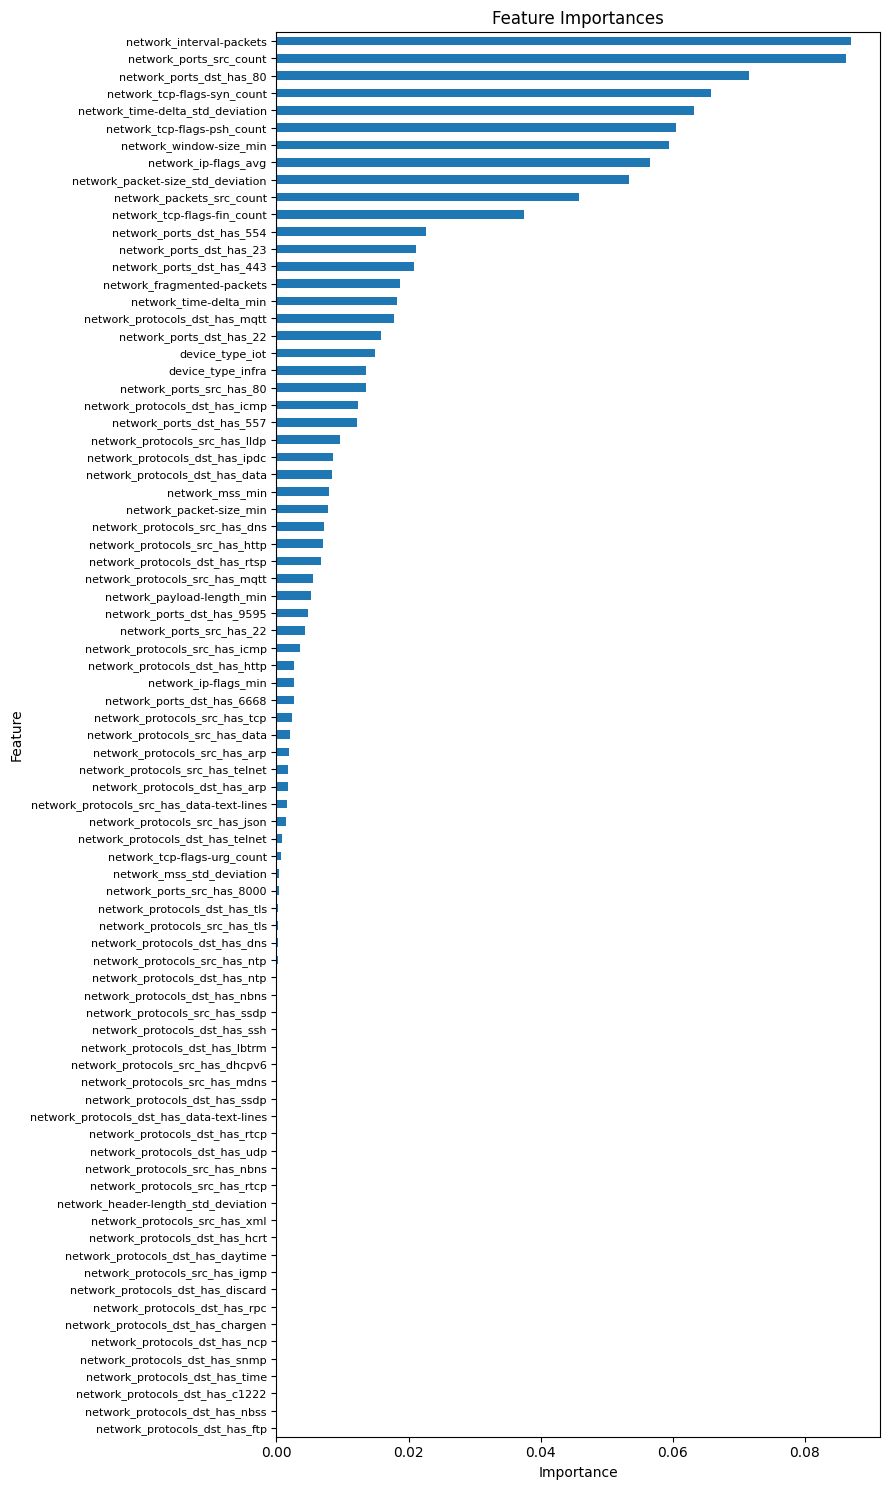

In [9]:
fig, ax = plt.subplots(figsize=(9, 15))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=8,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [10]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [12]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [13]:
total_n_nodes = sum(dtree.tree_.node_count for dtree in trained_model.estimators_)
total_n_leaves = sum(dtree.tree_.n_leaves for dtree in trained_model.estimators_)
total_depths = sum(dtree.tree_.max_depth for dtree in trained_model.estimators_)

model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "forest_structure": {
        "total_n_nodes": total_n_nodes,
        "mean_n_nodes": round(total_n_nodes / len(trained_model.estimators_), 2),
        "mean_n_leafs": round(total_n_leaves / len(trained_model.estimators_), 2),
        "mean_depth": round(total_depths / len(trained_model.estimators_), 2),
    }
}

model_summary = dumps(model_summary, indent=2, default=str)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__criterion": "gini",
    "model__max_features": 0.4,
    "model__max_leaf_nodes": 2400,
    "model__min_samples_leaf": 3,
    "model__n_estimators": 50
  },
  "all_parameters": {
    "bootstrap": false,
    "ccp_alpha": 0.0,
    "class_weight": {
      "benign": 0.33,
      "bruteforce_dictionary-ssh": 1.04,
      "bruteforce_dictionary-telnet": 1.11,
      "ddos_ack-frag-flood-port-1883": 1.09,
      "ddos_ack-frag-flood-port-80": 1.48,
      "ddos_connect-flood": 16.3,
      "ddos_http-flood-port-1883": 1.09,
      "ddos_http-flood-port-80": 1.48,
      "ddos_icmp-flood": 0.63,
      "ddos_icmp-frag-flood": 0.63,
      "ddos_mqtt-publish-flood": 16.3,
      "ddos_push-ack-flood-port-1883": 1.09,
      "ddos_push-ack-flood-port-80": 1.48,
      "ddos_rst-fin-flood-port-1883": 1.09,
      "ddos_rst-fin-flood-port-80": 1.48,
      "ddos_slowloris-port-1883": 16.3,
      "ddos_slowloris-port-554": 16.3,
      "ddos_slowloris-port-80": 5.